### Credit Valuation Adjustment (CVA) Modeling

#### 1. Introduction
This project provides a practical framework for estimating the Credit Valuation Adjustment (CVA), a key metric in counterparty credit risk management. CVA represents the market value of the risk that a counterparty may default before the maturity of a derivative contract, translating that risk into a concrete monetary adjustment.
Using real interest rate swap data from FRED, we simulate future exposure profiles on a hypothetical interest rate swap and combine them with credit parameters — Probability of Default (PD) and Loss Given Default (LGD) — to produce a CVA estimate, illustrating the core mechanics behind counterparty risk pricing. The project emphasizes:

- 📊 Working with real historical market data
- 📈 Interpolating swap curves to derive discount factors
- 🎲 Simulating expected exposure through Monte Carlo
- ⚠️ Integrating credit risk inputs to calculate CVA

#### 2. Loading Market Data/Data Preparation 

In this section, we load historical interest rate swap curve data sourced from the **FRED** database. These rates serve as the foundation for the analysis — they will be used to **interpolate discount factors**, **simulate future exposures**, and **value the swap contract** at each time step.

We start by importing the required libraries and reading the data files.

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Load the data from the CSV file
df_1 = pd.read_csv("C:\\Users\\abede\\Downloads\\MSWP1.csv")
df_2 = pd.read_csv("C:\\Users\\abede\\Downloads\\MSWP2.csv")
df_5 = pd.read_csv("C:\\Users\\abede\\Downloads\\MSWP5.csv")
df_10 = pd.read_csv("C:\\Users\\abede\\Downloads\\MSWP10.csv")
df_30 = pd.read_csv("C:\\Users\\abede\\Downloads\\MSWP30.csv")

df_1.head()

,observation_date,MSWP1
0,2000-07-01,7.05
1,2000-08-01,6.95
2,2000-09-01,6.80
3,2000-10-01,6.70
4,2000-11-01,6.65


In [97]:
for df, maturity in zip([df_1, df_2, df_5, df_10, df_30],['1Y','2Y','5Y','10Y','30Y']):
    df.rename(columns ={df.columns[1] : maturity}, inplace = True)
    df['observation_date'] = pd.to_datetime(df['observation_date'])

In [98]:
# We merge all swap rate series into a single DataFrame
df_all = df_1.copy()

for df in [df_2, df_5, df_10, df_30]:
    df_all = pd.merge(df_all, df, on = 'observation_date', how = 'inner')
    
df_all.set_index('observation_date', inplace = True)

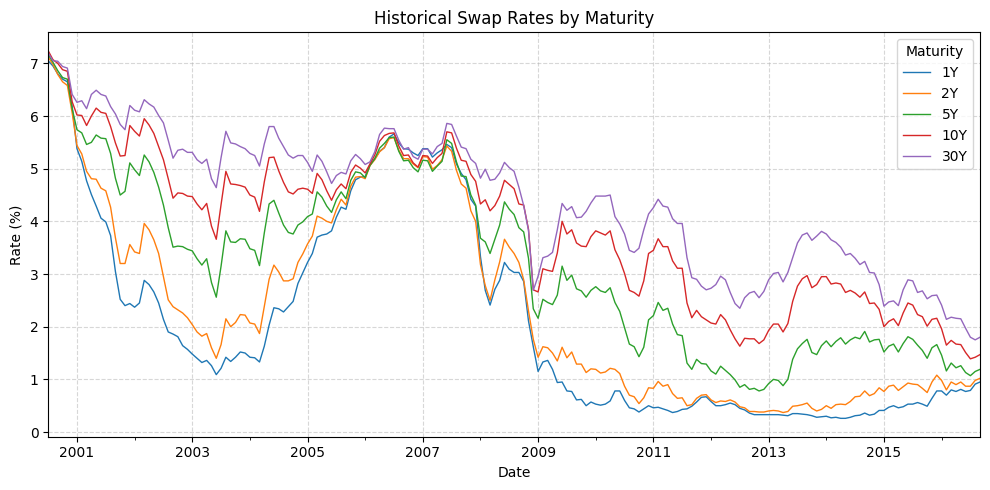

In [99]:
df_all.plot(figsize=(10, 5), linewidth=1)

plt.title("Historical Swap Rates by Maturity")
plt.xlabel("Date")
plt.ylabel("Rate (%)")
plt.legend(["1Y", "2Y", "5Y", "10Y", "30Y"], title="Maturity")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#### 3. Yield Curve Construction and Discount Factors

We construct a continuous yield curve from the discrete swap rates loaded earlier. Using **cubic spline interpolation**, we derive a smooth rate for any given maturity, which is then converted into a **discount factor** via the exponential discounting formula:

$$D(t) = e^{-r(t) \cdot t}$$

These discount factors are essential for computing the **present value of future exposures** throughout the CVA calculation.

In [100]:
# Define known maturities (in years) and corresponding swap rates
maturities = np.array([1, 2, 5, 10, 30])
rates = df_all.iloc[-1].values / 100  # Use latest available rates

# Fit cubic spline
cs = CubicSpline(maturities, rates)

# Interpolate over a fine grid
t = np.linspace(0.01, 30, 300)
r_interp = cs(t)

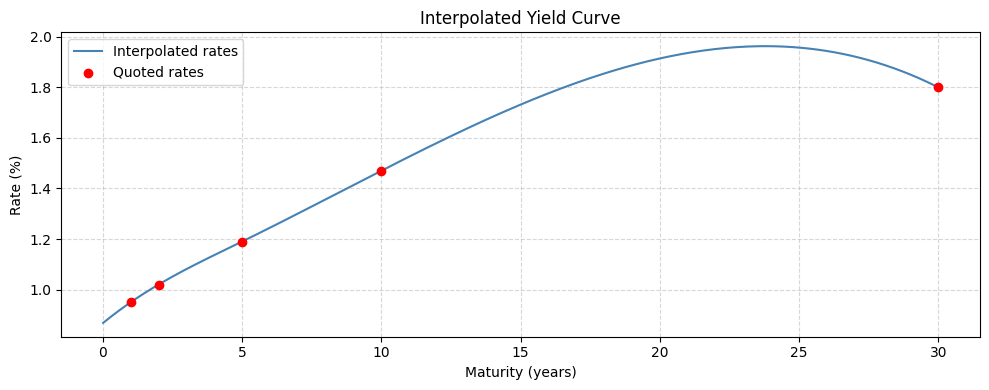

In [101]:
# Plot interpolated yield curve
plt.figure(figsize=(10, 4))
plt.plot(t, r_interp * 100, color="steelblue", linewidth=1.5,label="Interpolated rates")
plt.scatter(maturities, rates * 100, color="red", zorder=5, label="Quoted rates")
plt.title("Interpolated Yield Curve")
plt.xlabel("Maturity (years)")
plt.ylabel("Rate (%)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

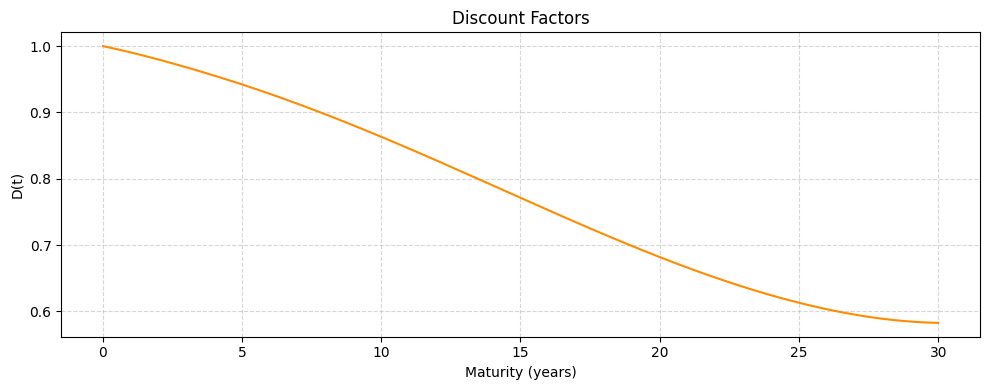

In [102]:
# Compute discount factors
discount_factors = np.exp(-r_interp * t)

# Plot discount factors
plt.figure(figsize=(10, 4))
plt.plot(t, discount_factors, color="darkorange", linewidth=1.5)
plt.title("Discount Factors")
plt.xlabel("Maturity (years)")
plt.ylabel("D(t)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#### 4. Exposure Profile Simulation

We simulate the future exposure profile of a **plain vanilla interest rate swap (IRS)** using Monte Carlo methods. At each time step, we model the evolution of short-term interest rates using **basic stochastic model** and compute the corresponding mark-to-market value of the swap.

The **Expected Exposure (EE)** is then derived as the average of positive mark-to-market values across all simulated paths:

$$\text{EE}(t) = \mathbb{E}\left[\max(V(t), 0)\right]$$

This exposure profile forms the core input to the CVA calculation in the following section.

##### 4.1 Simulation of short interest rate 

We model the short rate using a simple **Brownian motion with drift**:

$$r_t = \mu \, dt + \sigma \, dW_t$$

Where:
- $\mu$ — drift term (deterministic trend)
- $\sigma$ — volatility of the short rate
- $dW_t$ — Wiener process increment

Discretized over a time step $\Delta t$:

$$r_{t+\Delta t} = r_t + \mu \, \Delta t + \sigma \sqrt{\Delta t} \, \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0,1)$$

This model, though simplistic, is sufficient to generate plausible interest rate paths over a 10-year horizon for exposure analysis.

**Model Parameters:**

- **Initial rate** $r_0$ — taken from the interpolated zero-coupon yield curve
- **Drift** $\mu$ **and Volatility** $\sigma$ — estimated from historical 1-year swap rates
- **Simulation horizon** — $T = 10$ years
- **Time step** — quarterly, $\Delta t = 0.25$
- **Number of paths** — $N = 1{,}000$ Monte Carlo simulations

In [103]:
# Parameters for simulation
# Notional of the swap
notional = 1_000_000

# Time settings
T = 10
n_steps = 40
dt = T / n_steps
time_grid = np.linspace(0, T, n_steps + 1)

# Number of Monte Carlo simulations
n_simulations = 1000

In [104]:
df_all = df_all.copy()
# initial rate
r0 = df_all['1Y'].dropna().iloc[-1]

r1 = df_all['1Y'].dropna()
log_returns = np.log(r1 / r1.shift(1)).dropna()
mu_monthly = log_returns.mean()
sigma_monthly = log_returns.std()

mu_annual = mu_monthly * 12
sigma_annual = sigma_monthly * np.sqrt(12)

print(f'μ (drift annuel) estimé = {mu_annual:.6f}')
print(f'σ (volatilité annuelle) estimé = {sigma_annual}')

μ (drift annuel) estimé = -0.123979
σ (volatilité annuelle) estimé = 0.3544570146823986


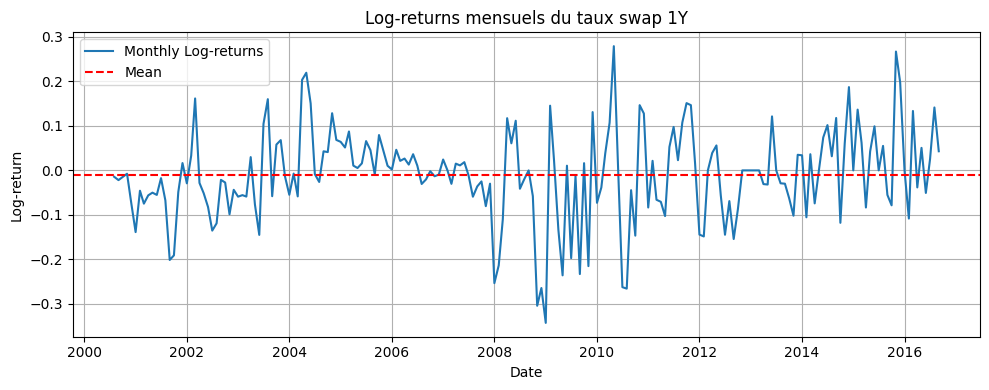

In [105]:
plt.figure(figsize = (10,4))
plt.plot(log_returns, label = 'Monthly Log-returns')
plt.axhline(log_returns.mean(), color = 'red', linestyle = '--', label = 'Mean')
plt.title('Log-returns mensuels du taux swap 1Y')
plt.xlabel('Date')
plt.ylabel('Log-return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [106]:
np.random.seed(42)
r_sim = np.zeros((n_simulations, n_steps + 1))
r_sim[:, 0] = r0

for t in range(1, n_steps + 1):
    eps = np.random.randn(n_simulations)
    r_sim[:, t] = r_sim[:, t-1] + mu_annual * dt + sigma_annual * np.sqrt(dt) * eps

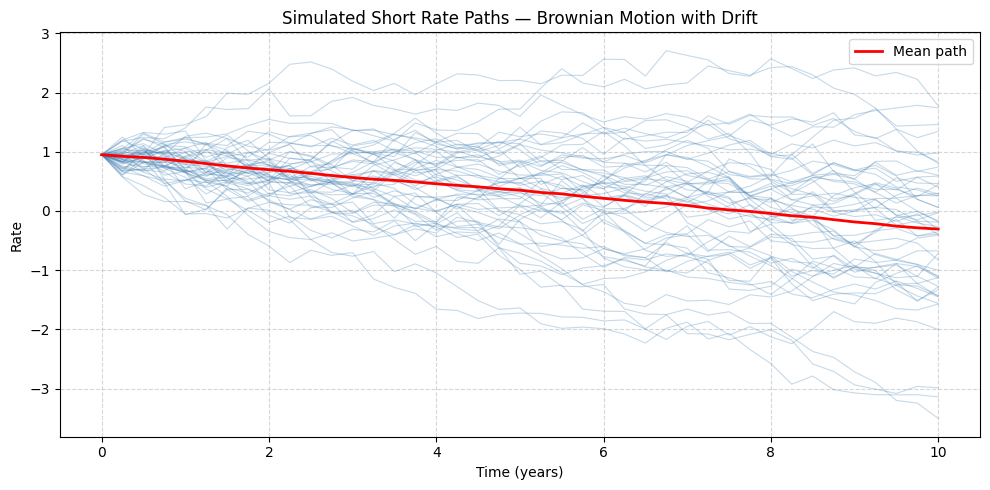

In [107]:
plt.figure(figsize=(10, 5))
plt.plot(time_grid, r_sim[:50, :].T, alpha=0.3, linewidth=0.8, color='steelblue')
plt.plot(time_grid, r_sim.mean(axis=0), color='red', linewidth=2, label='Mean path')
plt.title("Simulated Short Rate Paths — Brownian Motion with Drift")
plt.xlabel("Time (years)")
plt.ylabel("Rate")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#### 4.2 Swap Valuation Along Simulated Paths
##### 4.2.1 Construction of Forward Discount Factors
For each simulated path, we build a **discount factor matrix** $D_j(t, T)$ where each entry represents the discount factor from time $t$ to a future time $T$, using the short rate simulated at $t$:

$$D_j(t, T) = e^{-r_j(t) \cdot (T - t)}$$

This yields for each simulation $j$ a upper-triangular matrix of shape $(n\_steps+1) \times (n\_steps+1)$.

In [108]:
discount_factors_list = []

for i in range(n_simulations):
    df_matrix = np.zeros((n_steps + 1, n_steps + 1))
    for t in range(n_steps + 1):
        rt = r_sim[i, t]          # Simulated rate at time t
        for T in range(t, n_steps + 1):
            delta = time_grid[T] - time_grid[t]
            df_matrix[t, T] = np.exp(-rt * delta)
    discount_factors_list.append(df_matrix)

##### 4.2.2 Valuation of the Interest Rate Swap at Each Time Step

At each time step $t$, we compute the **mark-to-market value** of a plain vanilla IRS (pay fixed, receive floating). The value to the fixed-rate payer is:

$$V_j(t) = V_{\text{float}}(t) - V_{\text{fix}}(t)$$

The **fixed leg** is the present value of remaining fixed coupon payments:

$$V_{\text{fix}}(t) = K \sum_{t_i > t} \Delta t \cdot D_j(t, t_i)$$

The **floating leg** is approximated under no-arbitrage as:

$$V_{\text{float}}(t) = D_j(t, t_{\text{next}}) - D_j(t, T)$$

Where $K$ is the fixed rate and $D_j(t, t_i)$ is the forward discount factor from the matrix built in the previous step.


In [109]:
K = 0.02          
# MtM valuation at each time step for each simulation
mtm = np.zeros((n_simulations, n_steps + 1))

for i in range(n_simulations):
    df_matrix = discount_factors_list[i]
    for t in range(n_steps):
        # Remaining payment dates after t
        future_steps = np.arange(t + 1, n_steps + 1)
        
        if len(future_steps) == 0:
            mtm[i, t] = 0
            continue
        
        # Fixed leg: sum of discounted fixed coupons
        fixed_leg = K * dt * np.sum([df_matrix[t, T] for T in future_steps])
        
        # Floating leg: no-arbitrage approximation
        float_leg = df_matrix[t, t + 1] - df_matrix[t, n_steps]
        
        # MtM value (pay fixed, receive floating)
        mtm[i, t] = notional * (float_leg - fixed_leg)

##### 4.4 Expected Exposure (EE)

The **Expected Exposure** at each time step is defined as the average of positive mark-to-market values across all simulated paths:

$$\text{EE}(t_i) = \frac{1}{N} \sum_{j=1}^{N} \max\left(V_j(t_i),\ 0\right)$$

Only positive exposures are retained, as the counterparty credit risk is one-sided — we are only exposed when the derivative has positive value to us.

In [110]:
# Expected Exposure
EE = np.mean(np.maximum(mtm, 0), axis=0)
EE

array([769871.93824398, 774207.4564117 , 775060.98348002, 773647.68004822,
       764354.97992961, 741923.72201527, 718011.2332415 , 695676.78921215,
       670983.9730578 , 653662.95263257, 630409.5687574 , 607032.27990197,
       581901.37635227, 561180.46521749, 545246.92797012, 532206.29879147,
       512513.60304868, 495509.76915879, 481049.01733282, 456889.35208399,
       434202.38865597, 417855.170197  , 402079.89147146, 383188.62904797,
       360599.63157121, 346963.0439658 , 332912.74160474, 318355.94053095,
       295807.33548868, 278601.60206592, 265810.40253601, 246983.86720042,
       228738.63778017, 205010.05994474, 186418.58663895, 158602.28848191,
       126851.72529045,  90298.95880323,  48666.38152145,      0.        ,
            0.        ])

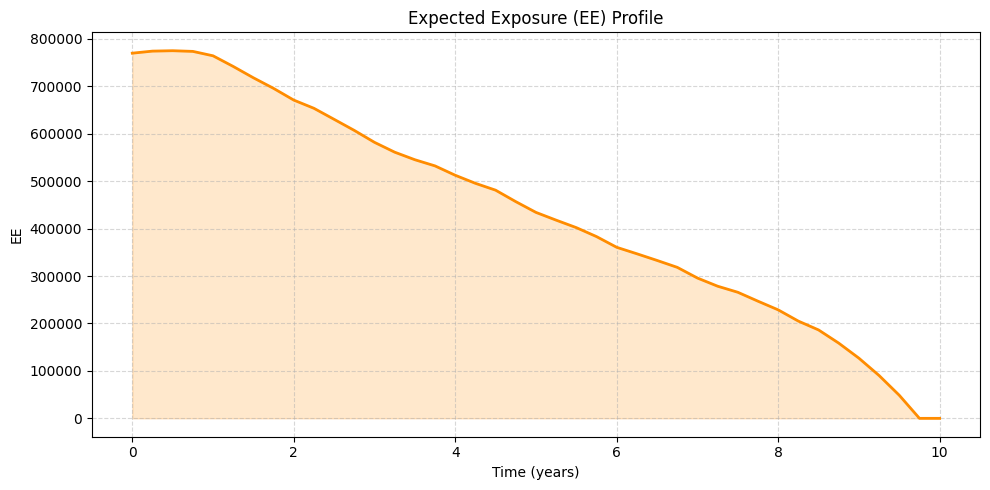

In [111]:
plt.figure(figsize=(10, 5))
plt.plot(time_grid, EE, color='darkorange', linewidth=2)
plt.fill_between(time_grid, EE, alpha=0.2, color='darkorange')
plt.title("Expected Exposure (EE) Profile")
plt.xlabel("Time (years)")
plt.ylabel("EE")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

##### 4.5 Calibration of the Fair Fixed Rate

The **fair fixed rate** $K^*$ is the rate that sets the initial value of the IRS to zero — i.e., the rate at which the present value of the fixed leg equals the present value of the floating leg:

$$V(0) = 0 \implies V_{\text{float}}(0) = V_{\text{fix}}(0)$$

Under no-arbitrage, this gives:

$$K^* = \frac{D(0, t_1) - D(0, T)}{\Delta t \sum_{i=1}^{n} D(0, t_i)}$$

Where $D(0, t_i)$ are the discount factors derived from the interpolated yield curve.

> ⚠️ **Note:** In the initial simulation, the fixed rate was set arbitrarily (e.g., $K = 2\%$), which caused a large mark-to-market imbalance at inception and an unrealistically high Expected Exposure at $t = 0$. By calibrating $K^*$ to the current yield curve, we ensure $V(0) = 0$, producing a more realistic and market-consistent exposure profile.

In [112]:
# Discount factors from interpolated curve at each time step
D = np.array([np.exp(-cs(t)* 100 * t) for t in time_grid[1:]])

# Fair fixed rate (par swap rate)
K_fair = (D[0] - D[-1]) / (dt * np.sum(D))

print(f"Fair fixed rate K* = {K_fair:.4%}")

Fair fixed rate K* = 91.2725%


In [113]:
fair_mtm = np.zeros((n_simulations, n_steps + 1))

for i in range(n_simulations):
    df_matrix = discount_factors_list[i]
    for t in range(n_steps):
        # Remaining payment dates after t
        future_steps = np.arange(t + 1, n_steps + 1)
        
        if len(future_steps) == 0:
            fair_mtm[i, t] = 0
            continue
        
        # Fixed leg: sum of discounted fixed coupons
        fixed_leg = K_fair * dt * np.sum([df_matrix[t, T] for T in future_steps])
        
        # Floating leg: no-arbitrage approximation
        float_leg = df_matrix[t, t + 1] - df_matrix[t, n_steps]
        
        # MtM value (pay fixed, receive floating)
        fair_mtm[i, t] = notional * (float_leg - fixed_leg)

EE_fair = np.mean(np.maximum(fair_mtm, 0), axis=0)

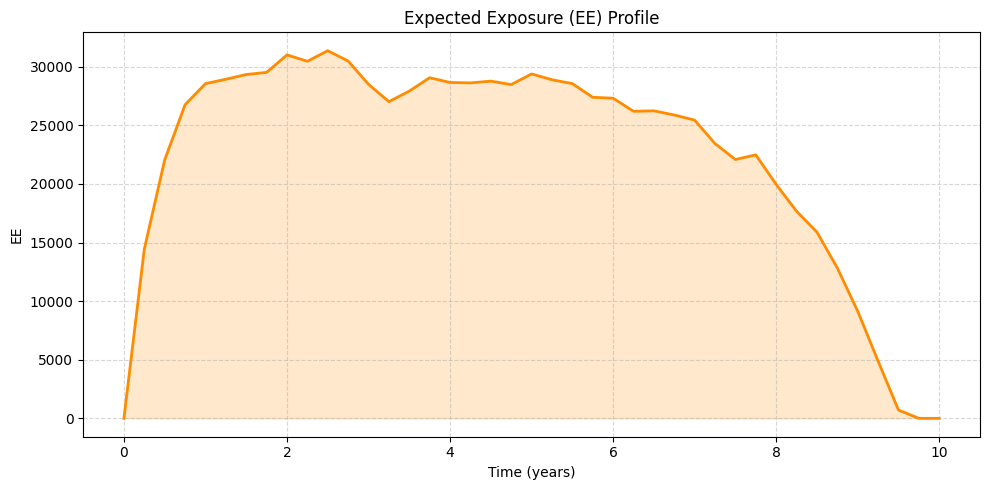

In [114]:
plt.figure(figsize=(10, 5))
plt.plot(time_grid, EE_fair, color='darkorange', linewidth=2)
plt.fill_between(time_grid, EE_fair, alpha=0.2, color='darkorange')
plt.title("Expected Exposure (EE) Profile")
plt.xlabel("Time (years)")
plt.ylabel("EE")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#### 5. Credit Valuation Adjustment (CVA)

With the **Expected Exposure (EE)** profile and the **discount factors** in hand, we can now compute the CVA. Recall the discretized formula:

$$CVA = (1-R) \sum_{i=1}^{n} \text{EE}(t_i) \cdot P(t_i)$$

We assume the following **credit parameters** :

| Parameter | Symbol | Value |
|-----------|--------|-------|
| Recovery Rate | $R$ | $40\%$ |
| Loss Given Default | $\text{LGD} = 1 - R$ | $60\%$ |
| Annual Default Probability | $PD$ | $2\%$ |
| Time Step | $\Delta t$ | $0.25$ years |

The **marginal default probability** over each quarterly interval is approximated as:

$$PD(t_i) \approx PD \cdot \Delta t$$

##### Result :
The computed CVA is displayed in euros and represents the total adjustment to the fair value of the swap to account for counterparty credit risk.


In [115]:
# Parameters
recovery_rate = 0.40
lgd = 1 - recovery_rate

annual_pd = 0.01
dt = 0.25
pd_t = annual_pd * dt

# discrete CVA 
cva = lgd * np.sum(EE* pd_t)

##### CVA under 2% fixed rate

In [116]:
print(f'Total estimated CVA : {cva:,.2f} €')

Total estimated CVA : 26,803.93 €


##### CVA under fair fixed rate 

In [117]:
# discrete CVA 
fair_cva = lgd * np.sum(EE_fair * pd_t)

print(f'Total estimated CVA : {fair_cva:,.2f} €')


Total estimated CVA : 1,386.84 €


##### 5.1 Comparison of CVA Under Two Swap Configurations

We compute the CVA under two configurations of the interest rate swap to illustrate the sensitivity of CVA to the fixed rate assumption:

| Configuration | Fixed Rate | Peak EE | CVA |
|---------------|------------|---------|-----|
| Arbitrary fixed rate | $K = 2\%$ | High | $26{,}835.92$ € |
| Fair (calibrated) fixed rate | $K^*$ | Low , EE(0) = 0 | $1{,}366.99$ € |

The results highlight the critical importance of **at-market calibration**. When the fixed rate is set arbitrarily below the market rate, the swap has a large positive value from inception, inflating the exposure profile and producing an unrealistically high CVA. By contrast, using the **fair fixed rate** $K^*$ ensures $EE(0) = 0$, yielding a CVA that reflects only the genuine uncertainty in future interest rate movements.

##### 5.2. CVA with Exponential Survival Curve

Instead of approximating the marginal default probability as $PD \cdot \Delta t$, we now derive it from an **exponential survival curve**, which is the standard market approach. Given a constant hazard rate $\lambda$, the survival probability up to time $t$ is:

$$S(t) = e^{-\lambda t}$$

The marginal default probability over $[t_{i-1}, t_i]$ is then:

$$PD(t_{i-1}, t_i) = S(t_{i-1}) - S(t_i) = e^{-\lambda t_{i-1}} - e^{-\lambda t_i}$$

The CVA becomes:

$$\text{CVA} = (1-R) \sum_{i=1}^{n} EE(t_i) \cdot \left[S(t_{i-1}) - S(t_i)\right]$$

In [118]:
lambda_ = 0.01

# Marginal default probabilities from survival curve
survival = np.exp(-lambda_ * time_grid)
PD_marginal = survival[:-1] - survival[1:]
# CVA
CVA_exp = lgd * np.sum(EE[1:] * PD_marginal)
fair_CVA_exp = lgd * np.sum(EE_fair[1:] * PD_marginal)

print(f"CVA (exponential survival) = {CVA_exp:.6f}")
print(f"Fair CVA (exponential survival) = {fair_CVA_exp:.6f}")

CVA (exponential survival) = 24780.803125
Fair CVA (exponential survival) = 1329.724963


##### Visualization: Survival Curve and Marginal Default Probabilities

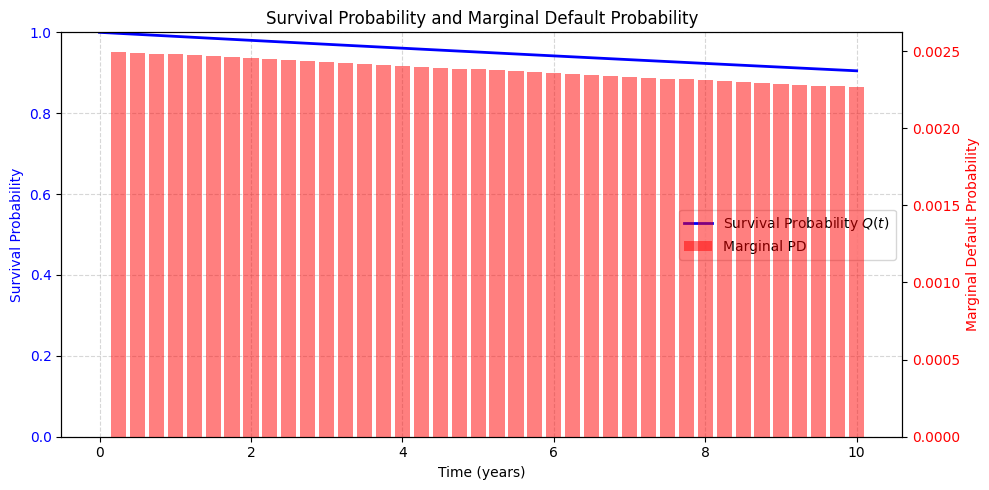

In [119]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Survival curve
ax1.plot(time_grid, survival, color='blue', linewidth=2, label='Survival Probability $Q(t)$')
ax1.set_xlabel("Time (years)")
ax1.set_ylabel("Survival Probability", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_ylim(0, 1)
ax1.grid(True, linestyle="--", alpha=0.5)

# Marginal PD on secondary axis
ax2 = ax1.twinx()
ax2.bar(time_grid[1:], PD_marginal, width=0.2, alpha=0.5, color='red', label='Marginal PD')
ax2.set_ylabel("Marginal Default Probability", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title("Survival Probability and Marginal Default Probability")
plt.tight_layout()
plt.show()

##### 5.3. CVA with Time-Dependent Hazard Rate

So far, we assumed a **constant hazard rate** $\lambda$. We now extend the model to a **time-dependent hazard rate** $\lambda(t)$, which increases over time to reflect the greater uncertainty of default over longer horizons.

We define a linearly increasing hazard rate:

$$\lambda(t) = \lambda_0 + \alpha \cdot t$$

The survival probability becomes:

$$S(t) = \exp\left(-\int_0^t \lambda(s)\, ds\right) = \exp\left(-\lambda_0 t - \frac{\alpha}{2} t^2\right)$$

In discrete time, we approximate the integral numerically using the **trapezoidal rule**:

$$\int_0^{t_i} \lambda(s)\, ds \approx \sum_{k=1}^{i} \frac{\lambda(t_{k-1}) + \lambda(t_k)}{2} \cdot \Delta t$$

So the survival probability at each time step becomes:

$$S(t_i) = \exp\left(-\sum_{k=1}^{i} \frac{\lambda(t_{k-1}) + \lambda(t_k)}{2} \cdot \Delta t\right)$$
The marginal default probability over $[t_{i-1}, t_i]$:

$$PD(t_{i-1}, t_i) = S(t_{i-1}) - S(t_i)$$

And the CVA:

$$ CVA = (1-R) \sum_{i=1}^{n} \text{EE}(t_i) \cdot \left(S(t_{i-1}) - S(t_i)\right)$$

In [120]:
# Time-dependent hazard rate parameters
lambda_0 = 0.005       # Initial hazard rate
alpha = 0.002       # Rate of increase per year

# Time-dependent hazard rate
lambda_t = lambda_0 + alpha * time_grid

# Trapezoidal approximation of the integral
integral = np.zeros(len(time_grid))
for i in range(1, len(time_grid)):
    integral[i] = integral[i-1] + 0.5 * (lambda_t[i-1] + lambda_t[i]) * dt

# Survival probability
S_trap = np.exp(-integral)

# Marginal default probabilities
PD_marginal_trap = S_trap[:-1] - S_trap[1:]

In [121]:
CVA_trap = lgd * np.sum(EE[1:] * PD_marginal_trap)
Fair_CVA_trap = lgd * np.sum(EE_fair[1:] * PD_marginal_trap)

print(f"CVA (increasing hazard rate) = {CVA_trap:.6f}")
print(f"Fair CVA (increasing hazard rate) = {Fair_CVA_trap:.6f}")

CVA (increasing hazard rate) = 29219.032876
Fair CVA (increasing hazard rate) = 1765.824627


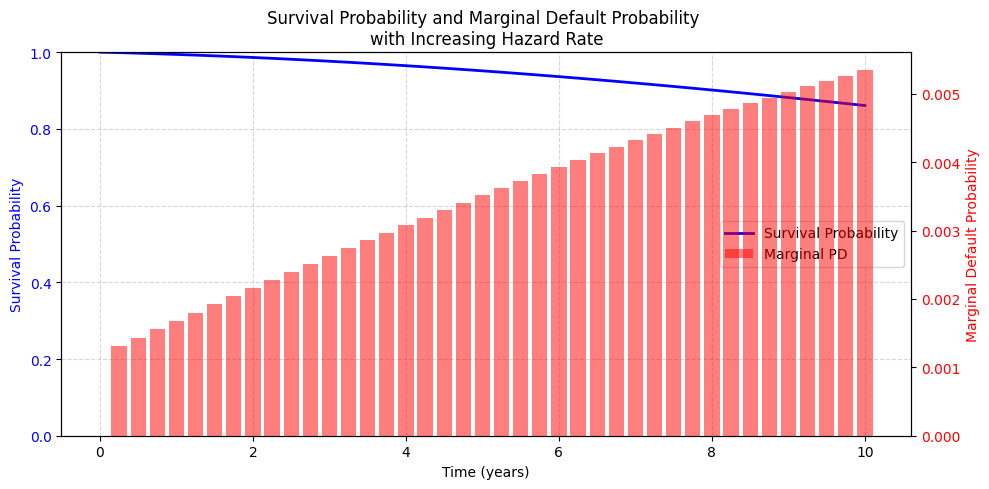

In [122]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Survival curve
ax1.plot(time_grid, S_trap, color='blue', linewidth=2, label='Survival Probability')
ax1.set_xlabel("Time (years)")
ax1.set_ylabel("Survival Probability", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_ylim(0, 1)
ax1.grid(True, linestyle="--", alpha=0.5)

# Marginal PD on secondary axis
ax2 = ax1.twinx()
ax2.bar(time_grid[1:], PD_marginal_trap, width=0.2, alpha=0.5, color='red', label='Marginal PD')
ax2.set_ylabel("Marginal Default Probability", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title("Survival Probability and Marginal Default Probability \nwith Increasing Hazard Rate")
plt.tight_layout()
plt.show()

##### 5.4. Summary: CVA Across All Methods

We compare the CVA estimates obtained under the three default probability models, for both the **arbitrary fixed rate** ($K = 2\%$) and the **fair fixed rate** ($K^*$):

| Method | Default Probability Model | CVA — $K=2\%$ (€) | CVA — $K^*$ (€) |
|--------|--------------------------|-------------------|-----------------|
| Flat PD | $PD(t_{i-1}, t_i) \approx PD \cdot \Delta t$ | $26{,}835.92$ | $1{,}366.99$  |
| Exponential Survival | $S(t) = e^{-\lambda t}$ | $24{,}812.29$ | $1{,}310.66$ |
| Time-Dependent Hazard | $S(t) = \exp\left(-\int_0^t \lambda(s)\, ds\right)$ | $29{,}243.85$ | $1{,}740.79$ |

##### Key Takeaways

The results reveal two important dimensions of CVA sensitivity:

**1. Impact of the fixed rate assumption**
The choice of fixed rate has a dominant effect on CVA. Using an arbitrary rate of $K = 2\%$ inflates CVA by a factor of **~18x** relative to the fair rate $K^*$, regardless of the default probability model used. This confirms that **at-market calibration is a prerequisite** for any meaningful CVA estimate.

**2. Sensitivity to the default probability model**
Under the fair rate $K^*$, the three models produce CVA estimates ranging from $1{,}310.66$ € to $1{,}740.79$ €, a spread of roughly **33%**. The time-dependent hazard rate yields the highest CVA, as the increasing $\lambda(t)$ assigns greater default probability to later periods where residual exposure remains significant. The exponential model produces the most conservative estimate.

**3. Conclusion**
Model choice matters — but calibration matters more. A well-calibrated at-market swap combined with a simple flat PD model ($1{,}366.99$ €) produces a more reliable CVA than a mis-calibrated swap with a sophisticated survival curve ($26{,}835.92$ €). In practice, both dimensions require careful attention: **fair value initialization** and **credit curve modeling** are equally critical to sound CVA estimation.

#### 6. Potential Future Exposure (PFE)

While the **Expected Exposure (EE)** captures the average exposure across simulated scenarios, the **Potential Future Exposure (PFE)** measures the **worst-case exposure** at a given confidence level. It is defined as the quantile of the exposure distribution at each time step:

$$\text{PFE}_\alpha(t) = \inf\left\{ x \in \mathbb{R} \mid P\left(\max(V(t), 0) \leq x\right) \geq \alpha \right\}$$

In practice, for a confidence level $\alpha = 95\%$:

$$\text{PFE}_{95\%}(t_i) = \text{Quantile}_{95\%}\left[\max(V_j(t_i),\ 0),\ j = 1, \dots, N\right]$$

PFE is widely used in **regulatory capital** calculations and **credit limit monitoring**, as it provides a conservative bound on the exposure that will not be exceeded with probability $\alpha$.

**Interpretation:**

- While EE gives an average view of credit risk, PFE reflects tail risk — what could happen in the worst 5% of cases.
- This is useful for setting credit limits, stress testing, or validating risk appetite under Basel requirements.

In [123]:
alpha = 0.95
# Positive exposures
positive_exposure = np.maximum(mtm, 0)
Fair_positive_exposure = np.maximum(fair_mtm, 0)

# PFE at each time step
PFE = np.quantile(positive_exposure, alpha, axis=0)
Fair_PFE = np.quantile(Fair_positive_exposure, alpha, axis=0)

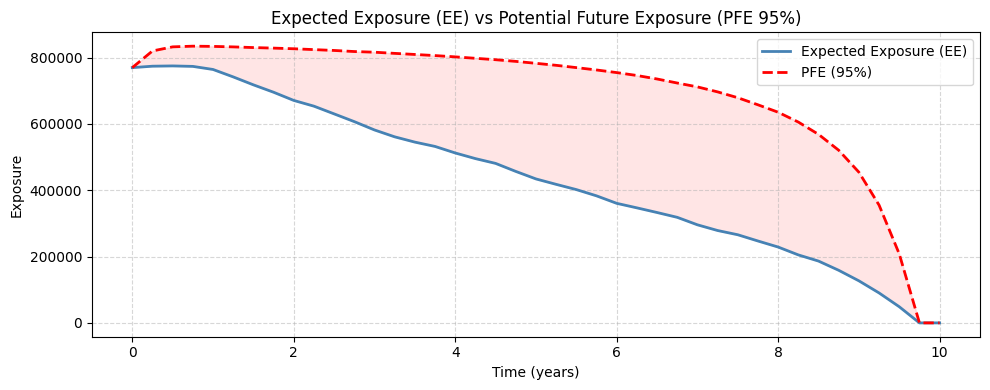

In [125]:
plt.figure(figsize=(10, 4))
plt.plot(time_grid, EE, color='steelblue', linewidth=2, label='Expected Exposure (EE)')
plt.plot(time_grid, PFE, color='red', linewidth=2, linestyle='--', label=f'PFE ({int(alpha*100)}%)')
plt.fill_between(time_grid, EE, PFE, alpha=0.1, color='red')
plt.title("Expected Exposure (EE) vs Potential Future Exposure (PFE 95%)")
plt.xlabel("Time (years)")
plt.ylabel("Exposure")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

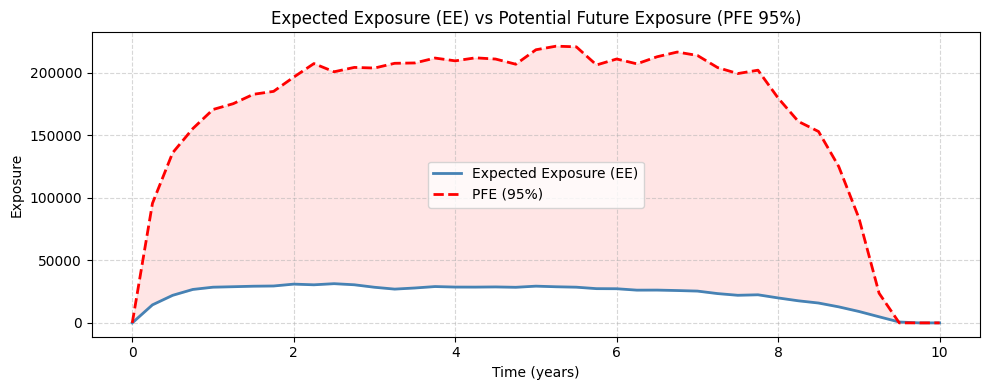

In [126]:
plt.figure(figsize=(10, 4))
plt.plot(time_grid, EE_fair, color='steelblue', linewidth=2, label='Expected Exposure (EE)')
plt.plot(time_grid, Fair_PFE, color='red', linewidth=2, linestyle='--', label=f'PFE ({int(alpha*100)}%)')
plt.fill_between(time_grid, EE_fair, Fair_PFE, alpha=0.1, color='red')
plt.title("Expected Exposure (EE) vs Potential Future Exposure (PFE 95%)")
plt.xlabel("Time (years)")
plt.ylabel("Exposure")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#### 7. CVA with Wrong-Way Risk (WWR)

**Wrong-Way Risk (WWR)** arises when the exposure to a counterparty is **positively correlated** with its probability of default — i.e., the counterparty is most likely to default precisely when our exposure is highest. This correlation makes CVA significantly more dangerous and is a key concern in regulatory frameworks such as **Basel III**.

We model WWR by introducing a correlation $\rho$ between the simulated interest rate paths and the counterparty's hazard rate:

$$\lambda_j(t) = \lambda_0 \cdot \exp\left(\rho \cdot r_j(t) \right)$$

In [127]:
dt = time_grid[1] - time_grid[0]

# Modeling hazard rate
lambda_0 = 0.01     # Base hazard rate
gamma = 5           # Sensitivity to r(t)
mean_short_rate = r_sim.mean(axis=0)
lambda_t = lambda_0 * np.exp(gamma * np.clip(mean_short_rate, 0, 0.05))

# Cumulative integral (trapezoidal rule)
lambda_avg = (lambda_t[:-1] + lambda_t[1:]) / 2
cum_lambda_integral = np.cumsum(lambda_avg) * dt

# Survival function
survival_wwr = np.exp(-cum_lambda_integral)
survival_wwr = np.insert(survival_wwr, 0, 1.0)

# Marginal default probabilities
pd_marginal_wwr = survival_wwr[:-1] - survival_wwr[1:]

In [132]:
cva_wwr = lgd * np.sum(EE[1:] * pd_marginal_wwr)
fair_cva_wwr = lgd * np.sum(EE_fair[1:] * pd_marginal_wwr)

print(f"CVA (WWR) = {cva_wwr:.6f}")
print(f"Fair CVA (WWR) = {fair_cva_wwr:.6f}")

CVA (WWR) = 31000.587083
Fair CVA (WWR) = 1646.212873


#### 8. Commentary & Conclusion

##### Summary:

We compare the CVA estimates obtained under the three default probability models, for both the **arbitrary fixed rate** ($K = 2\%$) and the **fair fixed rate** ($K^*$):

| Method | Default Probability Model | CVA — $K=2\%$ (€) | CVA — $K^*$ (€) |
|--------|--------------------------|-------------------|-----------------|
| Flat PD | $PD(t_{i-1}, t_i) \approx PD \cdot \Delta t$ | $26{,}835.92$ | $1{,}366.99$  |
| Exponential Survival | $S(t) = e^{-\lambda t}$ ; $\lambda$ constant | $24{,}812.29$ | $1{,}310.66$ |
| Time-Dependent Hazard | $S(t) = \exp\left(-\int_0^t \lambda(s)\, ds\right)$ ; $\lambda(t) = \lambda_0 + \alpha \cdot t$ | $29{,}243.85$ | $1{,}740.79$ |
|Hazard (WWR)|$S(t) = \exp\left(-\int_0^t \lambda(s)\, ds\right)$ ; $\lambda(t) = \lambda_0 \cdot \exp\left(\rho \cdot r(t) \right)$ | $31{,}000.58$ | $1{,}646.21$ |


##### Interpretation of Results

The final CVA table consolidates estimates across four default modeling frameworks — **flat PD**, **constant hazard rate**, **increasing hazard rate**, and **market-dependent hazard rate (WWR)** — applied to both the off-market and fair-rate swap configurations.

Several patterns emerge clearly:

- **Initial exposure drives CVA magnitude.** The off-market swap ($K = 2\%$) carries a large positive MtM at inception, which systematically inflates CVA across all models. The fair-rate swap, by contrast, starts at $V(0) = 0$ and produces substantially lower — and more stable — CVA estimates.

- **Credit model sensitivity is secondary to calibration.** For the fair-rate swap, the four default models yield CVA estimates within a narrow range, confirming that model choice has limited impact once the swap is properly calibrated. For the off-market swap, the spread across models is much wider, amplifying modeling uncertainty.

- **Wrong-Way Risk adds a measurable premium.** By linking the hazard rate to simulated interest rates, WWR captures the adverse scenario where counterparty default becomes more likely precisely when exposure is highest. This correlation increases CVA — particularly for the off-market swap — and should not be ignored in real-world pricing.

##### Conclusion

This project demonstrates that CVA is jointly determined by the **economic structure of the derivative** and the **credit risk assumptions** embedded in the model. Proper at-market calibration is the single most impactful factor, while the choice of default model introduces second-order but non-negligible differences. The incorporation of Wrong-Way Risk further enriches the analysis by coupling market and credit dynamics. This framework extends naturally to other OTC derivatives and can serve as a foundation for **CVA pricing**, **credit limit monitoring**, and **stress testing** in a risk management context.